In [9]:
import tensorflow as tf 
from collections import Counter
from tensorflow.keras import models, layers
from tensorflow import keras 

In [11]:
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 16

In [12]:
train_ds = keras.utils.image_dataset_from_directory(
    "../dataset/train",
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 8582 files belonging to 2 classes.
Using 6866 files for training.
Using 1716 files for validation.


In [13]:
train_ds, val_ds = train_ds

In [15]:
normalization_layer = layers.Rescaling(1./255)

In [16]:

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (normalization_layer(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x,y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

In [20]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    return x

def depthwise_block(x, filters):
    x = layers.SeparableConv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.1)(x)
    return x

In [21]:
inputs = keras.Input(shape=(*IMAGE_SIZE, 3))

x = conv_block(inputs, 32)
x = depthwise_block(x, 64)
x = depthwise_block(x, 128)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs) 

In [25]:
model.compile(
	optimizer=keras.optimizers.Adam(1e-4),
	loss="binary_crossentropy",
	metrics=["accuracy", keras.metrics.AUC(name="auc")] 
) 

In [27]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 conv2d_1 (Conv2D)           (None, 160, 160, 32)      896       
                                                                 
 batch_normalization_2 (Batc  (None, 160, 160, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 80, 80, 32)       0         
 2D)                                                             
                                                                 
 separable_conv2d_1 (Separab  (None, 80, 80, 64)       2400      
 leConv2D)                                                       
                                                             

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


2025-11-14 07:43:07.243787: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [6866]
	 [[{{node Placeholder/_4}}]]
2025-11-14 07:43:07.245699: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [6866]
	 [[{{node Placeholder/_0}}]]
2025-11-14 07:43:18.311937: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 52428800 exceeds 10% of free system memory.
2025-11-14 07:43:18.674805: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 52428800 exceeds 10% of free system memory.
2025-11-14 07:43:18.889369: W tenso

430/430 [==============================] - ETA: 0s - loss: 0.7536 - accuracy: 0.5058 - auc: 0.5104

2025-11-14 07:51:57.900937: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1716]
	 [[{{node Placeholder/_4}}]]
2025-11-14 07:51:57.902203: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1716]
	 [[{{node Placeholder/_4}}]]


430/430 [==============================] - 562s 1s/step - loss: 0.7536 - accuracy: 0.5058 - auc: 0.5104 - val_loss: 0.6930 - val_accuracy: 0.5140 - val_auc: 0.5156
Epoch 2/10
430/430 [==============================] - 587s 1s/step - loss: 0.7281 - accuracy: 0.5278 - auc: 0.5367 - val_loss: 0.6850 - val_accuracy: 0.5519 - val_auc: 0.5910
Epoch 3/10
430/430 [==============================] - 555s 1s/step - loss: 0.7182 - accuracy: 0.5319 - auc: 0.5483 - val_loss: 0.6841 - val_accuracy: 0.5548 - val_auc: 0.6273
Epoch 4/10
430/430 [==============================] - 588s 1s/step - loss: 0.7084 - accuracy: 0.5424 - auc: 0.5668 - val_loss: 0.6808 - val_accuracy: 0.5420 - val_auc: 0.5823
Epoch 5/10
430/430 [==============================] - 549s 1s/step - loss: 0.6995 - accuracy: 0.5558 - auc: 0.5737 - val_loss: 0.6738 - val_accuracy: 0.5629 - val_auc: 0.6323
Epoch 6/10
430/430 [==============================] - 556s 1s/step - loss: 0.7003 - accuracy: 0.5536 - auc: 0.5693 - val_loss: 0.6681 - 

In [30]:
loss, acc, auc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}") 
print(f"Validation AUC: {auc:.4f}")

108/108 [==============================] - 38s 345ms/step - loss: 0.6773 - accuracy: 0.5501 - auc: 0.6076
Validation Accuracy: 0.5501
Validation AUC: 0.6076


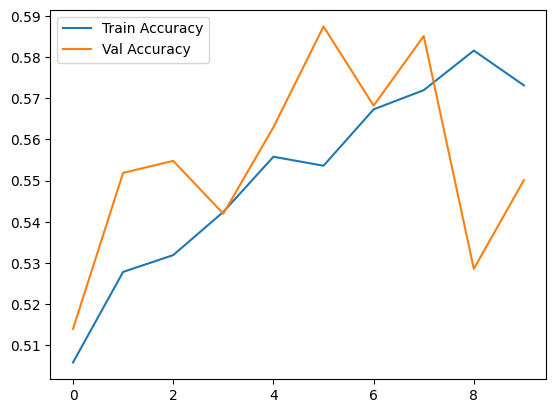

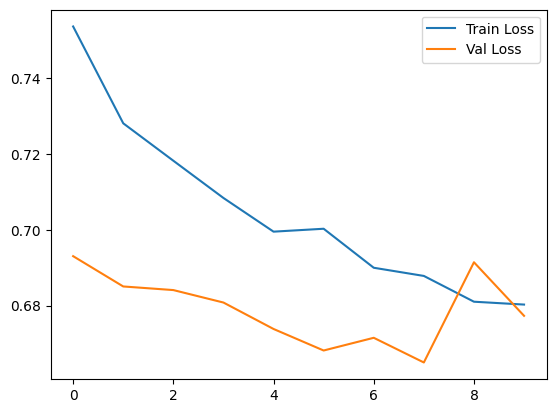

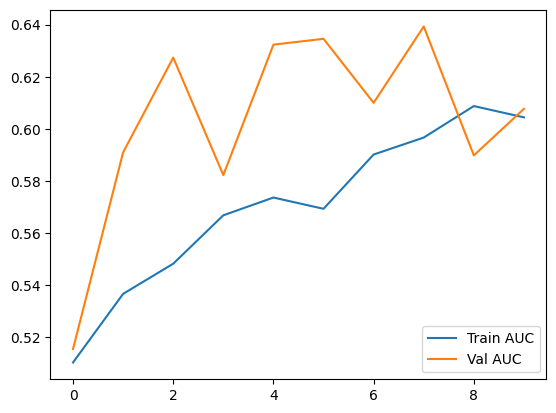

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.show()



In [33]:
model.save("my_cnn_model.h5")


2025-11-14 09:44:30.990697: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1716]
	 [[{{node Placeholder/_4}}]]
2025-11-14 09:44:30.992341: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1716]
	 [[{{node Placeholder/_4}}]]


1/1 [==============================] - 1s 962ms/step


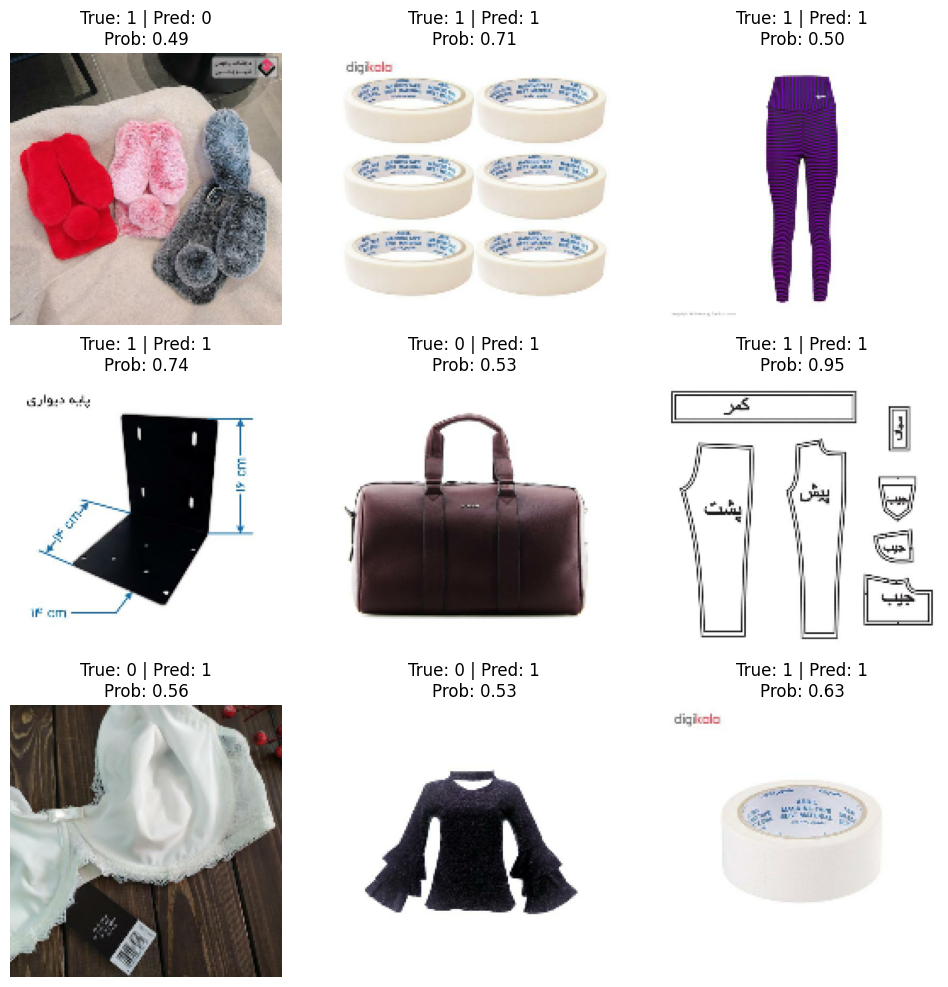

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load your saved model (or use the one already in memory)
model = tf.keras.models.load_model("my_cnn_model.h5")

# Take 1 batch from validation dataset
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    
    # Loop through first 9 images
    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        img = images[i].numpy()
        
        true_label = labels[i].numpy()
        pred_label = 1 if preds[i][0] > 0.5 else 0
        prob = preds[i][0]
        
        plt.imshow(img)
        plt.title(f"True: {true_label} | Pred: {pred_label}\nProb: {prob:.2f}")
        plt.axis("off")
    
    break
